# HCD-302 Creating Explainable AI — Lab 5
## Transparent Models: EBM vs Black Box

*สร้างโมเดลที่อ่านได้ทั้งตัว เทียบกับกล่องดำอย่างซื่อสัตย์ แล้วใช้ความโปร่งใสหาสิ่งที่ข้อมูลสอนผิด*

| | |
|---|---|
| **รายวิชา** | HCD-302 Creating Explainable AI |
| **สัปดาห์** | 6 · Transparent Models (Interpretable-by-Design) |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ |
| **เวลาทำแลป** | ในคาบประมาณ 30 นาที หลังเลกเชอร์ (พฤหัสบดี 15.30–17.20 น. ห้อง COC-404) |
| **กำหนดส่ง** | วันพฤหัสบดีที่ทำแลป ก่อนเวลา 18.00 น. ผ่าน LMS (lms.psu.ac.th) |
| **สิ่งที่ส่ง** | ไฟล์ `HCD302_Lab5_<รหัสนักศึกษา>.ipynb` ที่ **รันผลลัพธ์ไว้แล้ว** — ไฟล์ที่ไม่มีผลลัพธ์จะไม่ได้รับการตรวจ |
| **คะแนน** | 100 คะแนน คิดเป็นส่วนหนึ่งของคะแนน Lab (15% ของรายวิชา) · ทำเป็นรายบุคคล |

### 1. วัตถุประสงค์
เมื่อทำแลปนี้เสร็จ นักศึกษาจะสามารถ
1. อ่านสัมประสิทธิ์ของ logistic regression เป็น odds ratio และอ่านเส้นทางของต้นไม้ตัดสินใจ พร้อมบอกข้อจำกัดของทั้งสองแบบ
2. เทียบ Explainable Boosting Machine (EBM) กับโมเดลกล่องดำด้วย protocol เดียวกัน และตัดสินว่ามี trade-off ระหว่างความแม่นยำกับความโปร่งใสจริงหรือไม่ **บนข้อมูลชุดนี้**
3. อ่าน shape function ความสำคัญของแต่ละพจน์ และคำอธิบายรายบุคคลของ EBM ซึ่งเป็นผลบวกที่ **ตรงทุกตำแหน่งทศนิยม** ไม่ใช่ค่าประมาณ
4. ใช้ shape function ตรวจหาสิ่งที่โมเดลเรียนถูกตามข้อมูลแต่ผิดตามโลกจริง แล้ว **แก้ไขโมเดลโดยตรง** (แก้ค่า term, monotonize) พร้อมวัดต้นทุนของการแก้
5. เขียนข้อเสนอการนำไปใช้ และอธิบายผลรายผู้ป่วยให้แพทย์ที่ไม่ได้เรียน ML อ่านรู้เรื่อง

### 2. สถานการณ์
โรงพยาบาลแห่งหนึ่งต้องการโมเดลช่วยคัดกรอง **ผู้ป่วยปอดอักเสบที่ห้องฉุกเฉิน** ว่ารายใดมีความเสี่ยงต่ำพอจะ **ให้กลับไปรักษาตัวที่บ้าน** (เกณฑ์ที่เสนอ: ความเสี่ยงเสียชีวิตภายใน 30 วัน **ต่ำกว่า 5%**)
ข้อมูลย้อนหลังมีผู้ป่วย 6,000 รายที่ **รับไว้รักษาในโรงพยาบาลทุกราย** ตามแนวทางเดิม

ทีมวิเคราะห์ข้อมูลเสนอ gradient boosting ที่ได้คะแนนสูง และขออนุมัติใช้งาน ผู้อำนวยการฝ่ายการแพทย์ตอบว่า

> "ก่อนจะให้ใครกลับบ้านตามตัวเลขนี้ ผมต้องเห็นว่าโมเดลเรียนอะไรมา ทีละตัวแปร"

งานของแลปนี้คือสร้างโมเดลที่ **เปิดให้ดูได้ทั้งตัว** ตรวจว่ามันเรียนอะไรมา และตอบว่าต้องเสียความแม่นยำไปเท่าไรเพื่อแลกกับความโปร่งใสนั้น

### 3. โครงสร้างงาน (100 คะแนน)
| งาน | หัวข้อ | คะแนน |
|---|---|---|
| 1 | Classic glass boxes — odds ratio และต้นไม้ตัดสินใจ | 20 |
| 2 | EBM vs black box — protocol เดียวกัน ตารางเดียวกัน | 20 |
| 3 | Reading the glass box — ความสำคัญ, shape function, คำอธิบายรายบุคคล | 20 |
| 4 | Audit & edit — หา แก้ และวัดต้นทุนของการแก้ | 25 |
| 5 | Decision & communication — เปิดชุดทดสอบครั้งเดียว แล้วเขียนถึงแพทย์ | 15 |

## 0. Setup
รันเซลล์นี้ก่อน — ต้องการ `scikit-learn ≥ 1.4` และ `interpret ≥ 0.6` (InterpretML ของ Microsoft ซึ่งมี `ExplainableBoostingClassifier`)

In [1]:
import sys, time, copy, warnings, subprocess
try:
    import interpret
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "interpret"], check=True)
    import interpret

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 506
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("scikit-learn", sklearn.__version__, "| interpret", interpret.__version__)

scikit-learn 1.6.1 | interpret 0.7.8


### 0.1 ชุดข้อมูลและ data dictionary
ชุดข้อมูลสร้างขึ้นในเซลล์ถัดไปแบบ deterministic (seed 506) ทุกเครื่องจะได้ข้อมูลชุดเดียวกัน **ไม่ต้องดาวน์โหลดไฟล์ใด ๆ**
หนึ่งแถว = ผู้ป่วยหนึ่งราย (ไม่มีผู้ป่วยซ้ำ) บันทึกที่ห้องฉุกเฉินก่อนตัดสินใจรับไว้รักษา

| คอลัมน์ | ความหมาย | หน่วย / ค่า |
|---|---|---|
| `patient_id` | รหัสผู้ป่วย | — |
| `age` | อายุ | ปี |
| `male` | เพศชาย | 1 = ชาย |
| `nursing_home` | มาจากสถานดูแลผู้สูงอายุ | 0 / 1 |
| `has_asthma` | มีประวัติโรคหืด | 0 / 1 |
| `has_copd` | มีโรคปอดอุดกั้นเรื้อรัง | 0 / 1 |
| `has_chf` | มีภาวะหัวใจล้มเหลวเรื้อรัง | 0 / 1 |
| `has_diabetes` | มีเบาหวาน | 0 / 1 |
| `resp_rate` | อัตราการหายใจ | ครั้ง/นาที |
| `heart_rate` | อัตราการเต้นของหัวใจ | ครั้ง/นาที |
| `systolic_bp` | ความดันซิสโตลิก | mmHg |
| `temperature` | อุณหภูมิร่างกาย | °C |
| `spo2` | ความอิ่มตัวของออกซิเจนในเลือด | % |
| `bun` | blood urea nitrogen จากผลแล็บ | mg/dL |
| `died_30d` | **เป้าหมาย** เสียชีวิตภายใน 30 วัน | 1 = เสียชีวิต |

In [2]:
#@title 0.1 — สร้างชุดข้อมูล (ให้มาแล้ว · ห้ามแก้ไขฟังก์ชันนี้และห้ามเปลี่ยน seed)
def generate_pneumonia_data(n=6000, seed=506):
    """ผู้ป่วยปอดอักเสบสังเคราะห์ หนึ่งแถว = ผู้ป่วยหนึ่งราย (ห้ามแก้ seed)"""
    rng = np.random.default_rng(seed)
    sig = lambda z: 1/(1+np.exp(-z))
    age  = np.clip(rng.normal(62, 17, n), 18, 99).round().astype(int)
    male = rng.binomial(1, .52, n)
    nursing_home = rng.binomial(1, .35*sig((age-80)/4))
    copd     = rng.binomial(1, .08 + .14*(age > 60))
    chf      = rng.binomial(1, .04 + .22*sig((age-72)/7))
    diabetes = rng.binomial(1, .18, n)
    asthma   = rng.binomial(1, .10, n)
    s = rng.normal(0, 1, n)
    g = rng.normal(0, 1, n)
    resp_rate   = np.clip(19 + 3.2*s + 3*copd + 2*asthma + rng.normal(0, 3, n), 10, 50).round().astype(int)
    heart_rate  = np.clip(92 + 11*s + rng.normal(0, 12, n), 45, 170).round().astype(int)
    systolic_bp = np.clip(128 - 13*s + rng.normal(0, 16, n), 60, 210).round().astype(int)
    temperature = np.clip(37.9 + .55*s + rng.normal(0, .7, n), 34.5, 41.5).round(1)
    spo2        = np.clip(96 - 2.4*s - 2.5*copd - 1.5*asthma + rng.normal(0, 1.8, n), 70, 100).round().astype(int)
    bun_true    = np.clip(np.exp(np.log(15) + .22*s + .012*(age-60) + .35*chf + rng.normal(0, .35, n)), 3, 140)
    logit = (-3.9 + .02*(age-60) + .07*np.maximum(age-72, 0)
             + .2*np.maximum(resp_rate-23, 0) + .28*np.maximum(92-spo2, 0)
             + .05*np.maximum(100-systolic_bp, 0) + .03*np.maximum(bun_true-22, 0)
             + 1.6*np.maximum(temperature-39.0, 0) + 1.8*np.maximum(36.8-temperature, 0)
             + .018*np.maximum(heart_rate-110, 0)
             + .65*chf + .45*copd + .6*nursing_home + .2*diabetes + .15*male
             + .45*asthma
             + .02*np.maximum(age-70, 0)*np.maximum(93-spo2, 0)
             + .8*g + rng.normal(0, .3, n))
    h = asthma * rng.binomial(1, .9, n)
    died = rng.binomial(1, sig(logit - 2.6*h))
    o = rng.binomial(1, sig(1.0 + 1.0*s + 2.2*g + .04*(age-60) + 1.0*chf))
    bun = np.where(o == 1, bun_true.round().astype(int), 0)
    df = pd.DataFrame(dict(
        patient_id = rng.permutation(n) + 70000, age=age, male=male, nursing_home=nursing_home,
        has_asthma=asthma, has_copd=copd, has_chf=chf, has_diabetes=diabetes,
        resp_rate=resp_rate, heart_rate=heart_rate, systolic_bp=systolic_bp,
        temperature=temperature, spo2=spo2, bun=bun, died_30d=died))
    return df


df = generate_pneumonia_data()
FEATURES = [c for c in df.columns if c not in ("patient_id", "died_30d")]
print(df.shape, "| อัตราเสียชีวิต 30 วัน = %.1f%%" % (100*df.died_30d.mean()))
df.head()

(6000, 15) | อัตราเสียชีวิต 30 วัน = 10.5%


,patient_id,age,male,nursing_home,has_asthma,has_copd,has_chf,has_diabetes,resp_rate,heart_rate,systolic_bp,temperature,spo2,bun,died_30d
0,73424,66,0,0,0,0,0,0,24,88,99,36.2,97,0,0
1,74386,57,1,0,0,0,0,0,21,89,100,38.7,93,0,0
2,72199,73,0,0,0,0,0,0,26,109,130,37.5,96,24,0
3,71453,51,1,0,0,0,0,0,10,54,124,36.3,100,11,0
4,71202,72,1,0,0,0,0,1,18,87,140,37.5,96,26,0


### 0.2 ปิดผนึกชุดทดสอบ และ protocol (ให้มาแล้ว)
ผู้ป่วยแต่ละรายปรากฏครั้งเดียว และโมเดลจะใช้กับ **ผู้ป่วยรายใหม่ที่เข้ามาห้องฉุกเฉิน** การแบ่งแบบสุ่มที่รักษาสัดส่วน label (`StratifiedKFold`) จึงเลียนแบบการใช้งานได้ (ทบทวนสัปดาห์ที่ 5: *"ในการใช้งานจริง โมเดลจะให้คะแนนกับ ___"*)

- `dev` 75% → ใช้ทำทุกอย่างในงานที่ 1–4 (cross-validation ด้วย `cv` เท่านั้น)
- `test` 25% → **เปิดครั้งเดียว** ในงานที่ 5.1

In [3]:
# 0.2 — แบ่ง dev / test (ให้มาแล้ว ไม่ต้องแก้)
dev, test = train_test_split(df, test_size=0.25, stratify=df.died_30d, random_state=RANDOM_STATE)
dev, test = dev.reset_index(drop=True), test.reset_index(drop=True)
X_dev, y_dev = dev[FEATURES], dev.died_30d.values
X_test, y_test = test[FEATURES], test.died_30d.values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

HOME_THRESHOLD = 0.05          # ความเสี่ยง < 5% → เสนอให้กลับบ้าน
PATIENT_ID = 74975             # ผู้ป่วยที่ใช้ในงานที่ 3.3 และ 5.2
print(f"dev : {len(dev):,} ราย  อัตราเสียชีวิต {y_dev.mean()*100:.1f}%")
print(f"test: {len(test):,} ราย  (ปิดผนึกไว้ — ห้ามแตะจนถึงงานที่ 5.1)")

dev : 4,500 ราย  อัตราเสียชีวิต 10.6%
test: 1,500 ราย  (ปิดผนึกไว้ — ห้ามแตะจนถึงงานที่ 5.1)


### 0.3 ฟังก์ชันช่วยวาด shape function ของ EBM (ให้มาแล้ว)
`plot_shape(ebm, "age")` วาดค่าที่พจน์ของตัวแปรนั้นบวกเข้าไปใน **log-odds** ของความเสี่ยง (เส้นทึบ) พร้อมแถบ ±2 SD จาก bagging (สีจาง) และฮิสโตแกรมของข้อมูล (แท่งเทาด้านล่าง) — **อ่าน shape เฉพาะช่วงที่มีข้อมูลรองรับ**
ถ้าตัวแปรมีค่าหายไป (NaN) จะแสดงจุดสีแดงแยกทางซ้ายสุด ชื่อ `missing`

In [4]:
def plot_shape(ebm, name, ax=None, data=None, color="#1B2A4A"):
    """วาด shape function ของพจน์เดี่ยว (main effect) ของ EBM"""
    ax = ax or plt.gca()
    t = ebm.term_names_.index(name)
    f = list(ebm.feature_names_in_).index(name)
    cuts = np.asarray(ebm.bins_[f][0], dtype=float)
    sc = ebm.term_scores_[t]
    sd = ebm.standard_deviations_[t]
    sd = np.zeros_like(sc) if sd is None else sd       # หลัง monotonize จะไม่มีค่า SD
    lo, hi = ebm.feature_bounds_[f]
    edges = np.r_[lo, cuts, hi]
    x = np.repeat(edges, 2)[1:-1]
    yv = np.repeat(sc[1:-1], 2)
    ys = np.repeat(sd[1:-1], 2)
    ax.fill_between(x, yv - 2*ys, yv + 2*ys, color=color, alpha=.15, lw=0)
    ax.plot(x, yv, color=color, lw=2)
    ax.axhline(0, color="#6B7280", lw=.8, ls=":")
    if sc[0] != 0:
        ax.plot([lo - .06*(hi-lo)], [sc[0]], "o", color="#C8553D")
        ax.annotate("missing", (lo - .06*(hi-lo), sc[0]), textcoords="offset points",
                    xytext=(6, 4), fontsize=8, color="#C8553D")
    if data is not None:
        ax2 = ax.twinx()
        ax2.hist(data[name].dropna(), bins=40, color="#9CA3AF", alpha=.35)
        ax2.set_ylim(0, ax2.get_ylim()[1]*4)
        ax2.set_yticks([])
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("contribution to log-odds")
    return ax
print("plot_shape พร้อมใช้งาน")

plot_shape พร้อมใช้งาน


## งานที่ 1 — Classic Glass Boxes: odds ratio และต้นไม้ตัดสินใจ (20 คะแนน)

1. **Logistic regression** บนตัวแปรที่ standardize แล้ว: ทำตารางสัมประสิทธิ์ และ odds ratio **ต่อ 1 SD** เรียงจากมากไปน้อย วาดกราฟ odds ratio บนแกน log
2. แปลง odds ratio ของ `spo2` และ `age` กลับเป็น **หน่วยจริง** (ต่อ 1% และต่อ 10 ปี)
3. **Decision tree** ความลึก 3: cross-validate ROC-AUC วาดต้นไม้ และพิมพ์กฎด้วย `export_text`
4. **ความไม่เสถียร**: fit ต้นไม้ความลึก 3 บน bootstrap sample ของ `dev` 8 ครั้ง แล้วพิมพ์ตัวแปรและค่าตัดที่ root กับระดับถัดไป

,feature,coef_per_SD,odds_ratio_per_SD
0,age,0.674,1.962
1,bun,0.373,1.453
2,nursing_home,0.176,1.193
3,resp_rate,0.157,1.170
4,has_copd,0.126,1.134
5,has_chf,0.123,1.131
6,heart_rate,0.087,1.091
7,male,0.068,1.071
8,temperature,0.053,1.054
9,has_diabetes,0.053,1.054


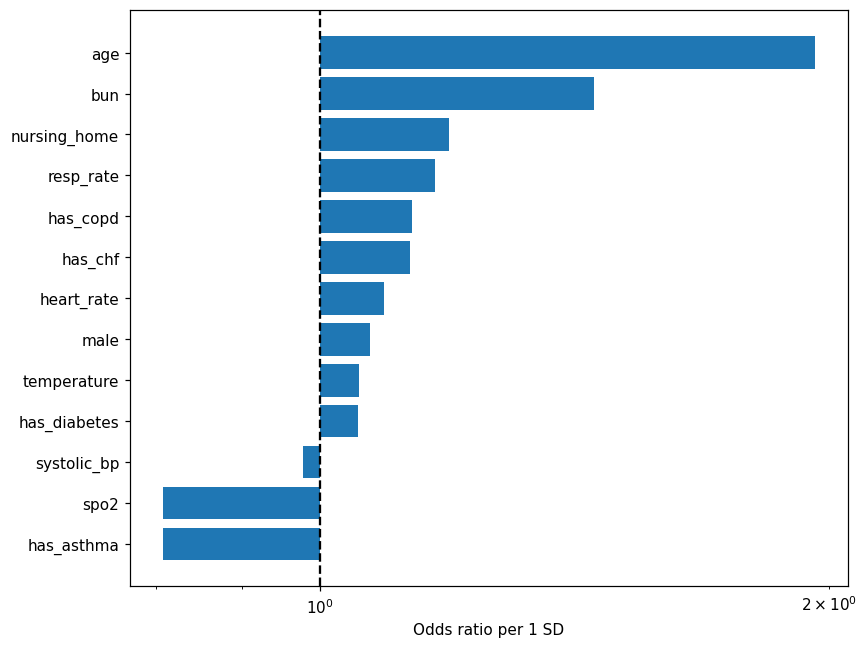

In [5]:
# TODO 1.1 — logistic regression → odds ratio ต่อ 1 SD
lr = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000))])
# ======== Edit Code Here =============
# 1) fit lr บน X_dev, y_dev
# 2) coef = สัมประสิทธิ์ของ LogisticRegression (ต่อ 1 SD เพราะ standardize แล้ว)
# 3) or_table = DataFrame คอลัมน์ feature, coef_per_SD, odds_ratio_per_SD เรียงจากมากไปน้อย
# 4) วาดกราฟแท่งแนวนอนของ odds ratio เริ่มที่ 1 (barh(..., OR - 1, left=1)) แกน x เป็น log scale พร้อมเส้นแนวตั้งที่ 1
lr.fit(X_dev, y_dev)
coef = lr.named_steps["model"].coef_[0]
or_table = pd.DataFrame({
    "feature": FEATURES,
    "coef_per_SD": coef,
    "odds_ratio_per_SD": np.exp(coef),
}).sort_values("odds_ratio_per_SD", ascending=False).reset_index(drop=True)
display(or_table.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = or_table.sort_values("odds_ratio_per_SD")
ax.barh(plot_data.feature, plot_data.odds_ratio_per_SD - 1, left=1)
ax.set_xscale("log")
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("Odds ratio per 1 SD")
plt.tight_layout()
# =====================================
plt.show()

In [6]:
# TODO 1.2 — กลับเป็นหน่วยจริง: coef ต่อหน่วย = coef ต่อ SD / SD ของตัวแปร
sd_ = lr.named_steps["scale"].scale_
# ======== Edit Code Here =============
b = dict(zip(FEATURES, coef / sd_))
or_spo2_per_1 = np.exp(b["spo2"])
or_age_per_10 = np.exp(10 * b["age"])
# =====================================
print(f"spo2 ลดลง 1%   → odds เสียชีวิตคูณ {1/or_spo2_per_1:.2f}")
print(f"อายุเพิ่ม 10 ปี → odds เสียชีวิตคูณ {or_age_per_10:.2f}")
print(f"has_asthma      → odds เสียชีวิตคูณ {np.exp(b['has_asthma']):.2f}  (มีโรคหืด เทียบกับไม่มี)")

spo2 ลดลง 1%   → odds เสียชีวิตคูณ 1.07
อายุเพิ่ม 10 ปี → odds เสียชีวิตคูณ 1.49
has_asthma      → odds เสียชีวิตคูณ 0.48  (มีโรคหืด เทียบกับไม่มี)


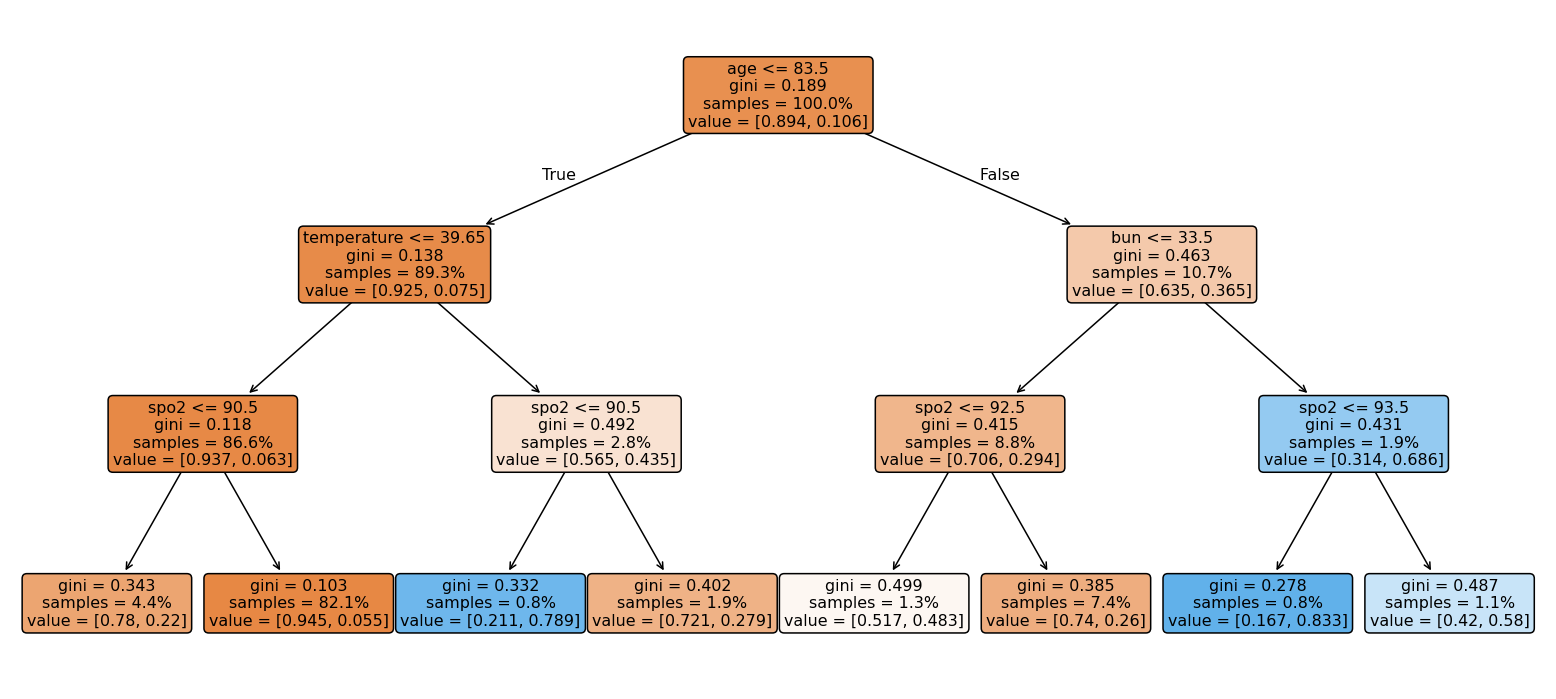

|--- age <= 83.50
|   |--- temperature <= 39.65
|   |   |--- spo2 <= 90.50
|   |   |   |--- class: 0
|   |   |--- spo2 >  90.50
|   |   |   |--- class: 0
|   |--- temperature >  39.65
|   |   |--- spo2 <= 90.50
|   |   |   |--- class: 1
|   |   |--- spo2 >  90.50
|   |   |   |--- class: 0
|--- age >  83.50
|   |--- bun <= 33.50
|   |   |--- spo2 <= 92.50
|   |   |   |--- class: 0
|   |   |--- spo2 >  92.50
|   |   |   |--- class: 0
|   |--- bun >  33.50
|   |   |--- spo2 <= 93.50
|   |   |   |--- class: 1
|   |   |--- spo2 >  93.50
|   |   |   |--- class: 1

Tree depth 3: ROC-AUC = 0.707 ± 0.015


In [7]:
# TODO 1.3 — ต้นไม้ความลึก 3
tree3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=RANDOM_STATE)
# ======== Edit Code Here =============
# 1) auc_tree3 = ROC-AUC จาก cross_validate(..., cv=cv) (array 5 ค่า)
# 2) fit tree3 บน dev ทั้งหมด แล้ววาดด้วย plot_tree(feature_names=FEATURES, proportion=True, filled=True)
# 3) พิมพ์กฎด้วย export_text
auc_tree3 = cross_validate(tree3, X_dev, y_dev, cv=cv, scoring="roc_auc")["test_score"]
tree3.fit(X_dev, y_dev)
plt.figure(figsize=(18, 8))
plot_tree(tree3, feature_names=FEATURES, proportion=True, filled=True, rounded=True)
plt.show()
print(export_text(tree3, feature_names=FEATURES))
# =====================================
print(f"Tree depth 3: ROC-AUC = {auc_tree3.mean():.3f} ± {auc_tree3.std():.3f}")

In [8]:
# TODO 1.4 — ต้นไม้เปลี่ยนไปแค่ไหนเมื่อข้อมูลเปลี่ยนเล็กน้อย
rng = np.random.default_rng(0)
rows = []
for b_ in range(8):
    idx = rng.integers(0, len(X_dev), len(X_dev))          # bootstrap sample
    # ======== Edit Code Here =============
    # fit DecisionTreeClassifier(max_depth=3, min_samples_leaf=30) บน X_dev.iloc[idx], y_dev[idx]
    # ใช้ t.tree_.feature, t.tree_.threshold, t.tree_.children_left/right
    # เก็บ dict {"bootstrap", "root", "left child", "right child"} เช่น "age ≤ 71.5" ลงใน rows
    t = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=RANDOM_STATE)
    t.fit(X_dev.iloc[idx], y_dev[idx])
    tr = t.tree_
    def split_at(node):
        if tr.feature[node] < 0:
            return "leaf"
        return f"{FEATURES[tr.feature[node]]} ≤ {tr.threshold[node]:.1f}"
    rows.append({"bootstrap": b_ + 1, "root": split_at(0),
                 "left child": split_at(tr.children_left[0]),
                 "right child": split_at(tr.children_right[0])})
    # =====================================
boot = pd.DataFrame(rows)
display(boot)
print("จำนวนโครงสร้าง (root, left, right) ที่ไม่ซ้ำกัน:", boot[["root", "left child", "right child"]].drop_duplicates().shape[0], "จาก 8")

,bootstrap,root,left child,right child
0,1,bun ≤ 32.5,age ≤ 82.5,age ≤ 87.5
1,2,age ≤ 83.5,temperature ≤ 39.8,bun ≤ 33.5
2,3,bun ≤ 31.5,age ≤ 84.5,age ≤ 79.5
3,4,age ≤ 83.5,temperature ≤ 39.6,bun ≤ 33.5
4,5,age ≤ 83.5,temperature ≤ 39.6,bun ≤ 36.5
5,6,age ≤ 85.5,bun ≤ 29.5,bun ≤ 32.5
6,7,age ≤ 82.5,temperature ≤ 39.6,bun ≤ 28.5
7,8,bun ≤ 31.5,age ≤ 72.5,nursing_home ≤ 0.5


จำนวนโครงสร้าง (root, left, right) ที่ไม่ซ้ำกัน: 8 จาก 8


**ข้อสังเกตงานที่ 1 (4 บรรทัด):**
1. ตัวแปรสามอันดับแรกของ odds ratio ต่อ 1 SD คืออะไร และทำไมต้องเทียบ "ต่อ 1 SD" แทนสัมประสิทธิ์ดิบ
2. odds ratio ของ `has_asthma` มีค่าเท่าไร และ **ขัดกับความรู้ทางการแพทย์หรือไม่** (ยังไม่ต้องอธิบายสาเหตุ — จดไว้ใช้ในงานที่ 4)
3. อ่านเส้นทางหนึ่งเส้นในต้นไม้ที่ไปจบที่ใบที่มีความเสี่ยงสูงสุด เป็นประโยคภาษาคนหนึ่งประโยค
4. ต้นไม้ 8 ต้นจาก bootstrap เหมือนกันแค่ไหน และข้อนี้บอกอะไรเกี่ยวกับการใช้ "คำอธิบายจากต้นไม้" ในการตัดสินใจ

1. อันดับแรกคือ `age` (OR 1.962), `bun` (1.453) และ `nursing_home` (1.193) ต่อ 1 SD; ต้องเทียบต่อ 1 SD เพราะแต่ละตัวแปรมีหน่วยและช่วงค่าต่างกัน
2. `has_asthma` มี OR 0.807 ต่อ 1 SD หรือประมาณ 0.48 เมื่อเทียบคนที่มีโรคหืดกับไม่มี โมเดลจึงบอกว่าโรคหืดสัมพันธ์กับความเสี่ยงที่ต่ำลง ซึ่งขัดกับสิ่งที่คาดทางคลินิก
3. ตัวอย่างเส้นทางไปใบเสี่ยงสูง: ผู้ป่วยอายุมากกว่า 83.5 ปี มี BUN มากกว่า 33.5 mg/dL และ SpO₂ ไม่เกิน 93.5% ถูกจัดอยู่ในกลุ่มเสี่ยงสูงของต้นไม้
4. ต้นไม้ bootstrap ทั้ง 8 ต้นมีชุด root และลูกสองข้างต่างกันทั้งหมด (8/8) จึงไม่ควรถือเส้นทางของต้นไม้เพียงต้นเดียวว่าเป็นเหตุผลที่มั่นคงของข้อมูล

## งานที่ 2 — EBM vs Black Box: protocol เดียวกัน ตารางเดียวกัน (20 คะแนน)

1. cross-validate ด้วย `cv` บน `dev` ทุกโมเดลต่อไปนี้ เก็บ ROC-AUC (mean ± sd), AP และเวลาที่ใช้
   - glass box: `LR` (จากงานที่ 1), `Tree d3` (จากงานที่ 1), `EBM` = `ExplainableBoostingClassifier(interactions=0, outer_bags=8, random_state=RANDOM_STATE)` (GAM ล้วน), `EBM+5 pairs` = เหมือนกันแต่ `interactions=5`
   - black box: `HGB default` = `HistGradientBoostingClassifier(random_state=RANDOM_STATE)`, `HGB tuned` = `max_depth=3, learning_rate=0.05`, `RF` = `RandomForestClassifier(300, min_samples_leaf=5, n_jobs=-1)`
2. วาดกราฟแท่ง ROC-AUC พร้อม error bar แยกสี glass box / black box

> EBM ใช้เวลา fit ประมาณ 5–20 วินาทีต่อ fold บน Colab — ทั้งเซลล์ใช้เวลาราว 1–2 นาที

In [9]:
# TODO 2.1 — ตารางเปรียบเทียบ
models = {
    "LR":          ("glass", lr),
    "Tree d3":     ("glass", tree3),
    # ======== Edit Code Here =============
    # เพิ่ม "EBM", "EBM+5 pairs", "HGB default", "HGB tuned", "RF" ตามโจทย์ ในรูปแบบ (type, model)
    "EBM": ("glass", ExplainableBoostingClassifier(interactions=0, outer_bags=8, random_state=RANDOM_STATE)),
    "EBM+5 pairs": ("glass", ExplainableBoostingClassifier(interactions=5, outer_bags=8, random_state=RANDOM_STATE)),
    "HGB default": ("black", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    "HGB tuned": ("black", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    "RF": ("black", RandomForestClassifier(300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)),
    # =====================================
}
rows = []
# ======== Edit Code Here =============
# วนทุกโมเดล: cross_validate(m, X_dev, y_dev, cv=cv, scoring=["roc_auc", "average_precision"])
# เก็บ dict {"model", "type", "auc_mean", "auc_sd", "ap_mean", "seconds"} ลง rows
for name, (kind, model) in models.items():
    start = time.perf_counter()
    scores = cross_validate(model, X_dev, y_dev, cv=cv,
                            scoring=["roc_auc", "average_precision"])
    rows.append({"model": name, "type": kind,
                 "auc_mean": scores["test_roc_auc"].mean(),
                 "auc_sd": scores["test_roc_auc"].std(),
                 "ap_mean": scores["test_average_precision"].mean(),
                 "seconds": time.perf_counter() - start})
# =====================================
comparison = pd.DataFrame(rows).sort_values("auc_mean", ascending=False).reset_index(drop=True)
print(f"base rate (พื้นของ AP) = {y_dev.mean():.3f}")
comparison.round(3)

base rate (พื้นของ AP) = 0.106


,model,type,auc_mean,auc_sd,ap_mean,seconds
0,EBM,glass,0.820,0.007,0.490,36.344
1,EBM+5 pairs,glass,0.818,0.005,0.481,46.854
2,HGB tuned,black,0.812,0.011,0.460,0.511
3,RF,black,0.807,0.014,0.457,8.647
4,HGB default,black,0.783,0.019,0.422,1.436
5,LR,glass,0.779,0.010,0.412,0.137
6,Tree d3,glass,0.707,0.015,0.304,0.083


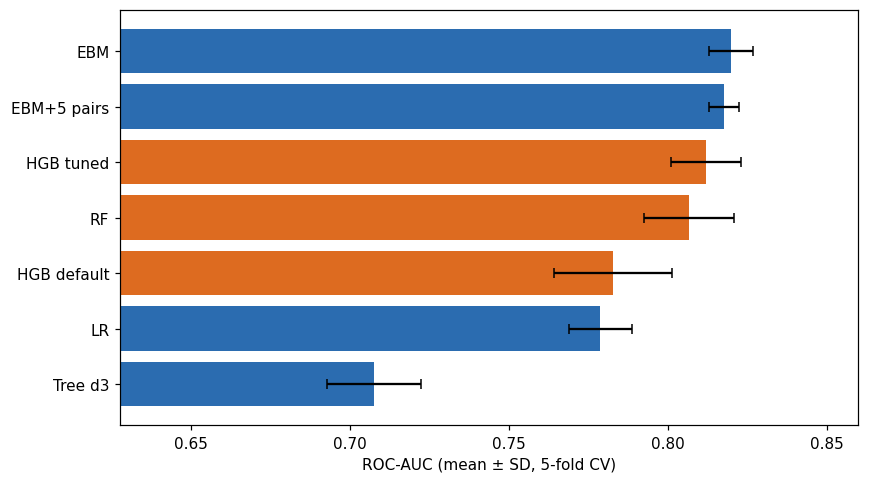

In [10]:
# TODO 2.2 — กราฟเปรียบเทียบ
# ======== Edit Code Here =============
# กราฟแท่งแนวนอน auc_mean พร้อม xerr=auc_sd สีต่างกันตาม type (glass / black) ตั้ง xlim ให้เห็นความต่าง
plot_data = comparison.sort_values("auc_mean")
colors = plot_data["type"].map({"glass": "#2B6CB0", "black": "#DD6B20"})
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_data.model, plot_data.auc_mean, xerr=plot_data.auc_sd,
        color=colors, capsize=3)
ax.set_xlim(max(0, plot_data.auc_mean.min() - 0.08), min(1, plot_data.auc_mean.max() + 0.04))
ax.set_xlabel("ROC-AUC (mean ± SD, 5-fold CV)")
plt.tight_layout()
# =====================================
plt.show()

**ข้อสังเกตงานที่ 2 (4 บรรทัด):**
1. โมเดลที่ดีที่สุดคืออะไร และห่างจากโมเดลอันดับสองกี่ sd — ความต่างนี้มีความหมายหรือไม่
2. บนข้อมูลชุดนี้ มี trade-off ระหว่างความแม่นยำกับความโปร่งใส **จริงหรือไม่** ตอบด้วยตัวเลขจากตาราง
3. ทำไม `HGB default` จึงแพ้ `HGB tuned` และข้อนี้บอกอะไรเกี่ยวกับการเปรียบเทียบ "โมเดลกล่องดำ" แบบไม่ได้ปรับ
4. การเพิ่ม pairwise interaction 5 คู่ช่วยหรือไม่ ถ้าไม่ช่วย ควรเลือกแบบไหนและเพราะอะไร

1. `EBM` ได้ ROC-AUC สูงสุด 0.820 รองลงมาคือ `EBM+5 pairs` 0.818 ต่างกัน 0.002 หรือราว 0.29 เท่าของ SD ของ EBM (0.007) จึงยังสรุปไม่ได้ว่าดีกว่าจริงจาก CV นี้
2. บนข้อมูลชุดนี้ไม่เห็นว่าต้องเสียความแม่นยำเพื่อให้โปร่งใส: EBM 0.820 ± 0.007 เทียบกับกล่องดำที่ดีที่สุด `HGB tuned` 0.812 ± 0.011 ต่างกัน 0.008 ซึ่งยังใกล้กับความแปรปรวนของ CV
3. `HGB default` ได้ 0.783 ส่วน `HGB tuned` ได้ 0.812; การปรับความลึกและ learning rate ช่วยมาก จึงไม่ควรใช้รุ่นค่าตั้งต้นเพียงรุ่นเดียวแทนความสามารถทั้งหมดของกล่องดำ
4. เพิ่ม interaction 5 คู่แล้ว ROC-AUC ลดจาก 0.820 เป็น 0.818 และ AP ลดจาก 0.490 เป็น 0.481 จึงเลือก EBM แบบไม่มี interaction เพราะอ่านง่ายกว่าและผลไม่ได้ด้อยกว่า

## งานที่ 3 — Reading the Glass Box: อ่านโมเดลทั้งตัว (20 คะแนน)

ใช้ EBM แบบไม่มี interaction (GAM ล้วน) เพราะงานที่ 2 แสดงว่าไม่เสียความแม่นยำ และอ่านง่ายกว่า

1. fit `ebm` บน `dev` ทั้งหมด วาดกราฟ **term importance** (`ebm.term_importances()`) เรียงจากมากไปน้อย
2. วาด shape function ด้วย `plot_shape` ของ 6 ตัวแปรที่สำคัญที่สุดที่เป็นตัวเลขต่อเนื่อง ในตาราง 2 × 3 (ส่ง `data=dev` เพื่อให้เห็นฮิสโตแกรม)
3. คำอธิบายรายบุคคลของผู้ป่วย `PATIENT_ID`: ใช้ `ebm.eval_terms()` หา contribution ของทุกพจน์ วาดกราฟแท่ง แล้ว **พิสูจน์** ว่า intercept + ผลรวม contribution = `ebm.decision_function()` และแปลงเป็นความน่าจะเป็นได้เท่ากับ `predict_proba`

,importance
age,0.469
bun,0.320
temperature,0.211
resp_rate,0.143
has_asthma,0.128
has_copd,0.124
has_chf,0.110
spo2,0.106
nursing_home,0.094
heart_rate,0.078


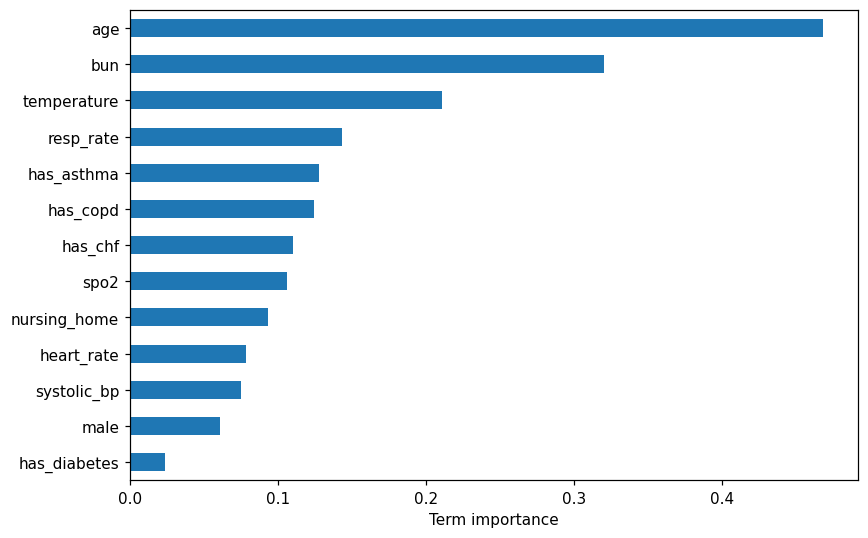

In [11]:
# TODO 3.1 — fit EBM และ term importance
ebm = ExplainableBoostingClassifier(interactions=0, outer_bags=8, random_state=RANDOM_STATE)
# ======== Edit Code Here =============
# fit ebm บน dev แล้ววาดกราฟแท่งแนวนอนของ ebm.term_importances() (index = ebm.term_names_)
ebm.fit(X_dev, y_dev)
imp = pd.Series(ebm.term_importances(), index=ebm.term_names_).sort_values(ascending=False)
display(imp.round(3).rename("importance"))
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Term importance")
plt.tight_layout()
# =====================================
plt.show()

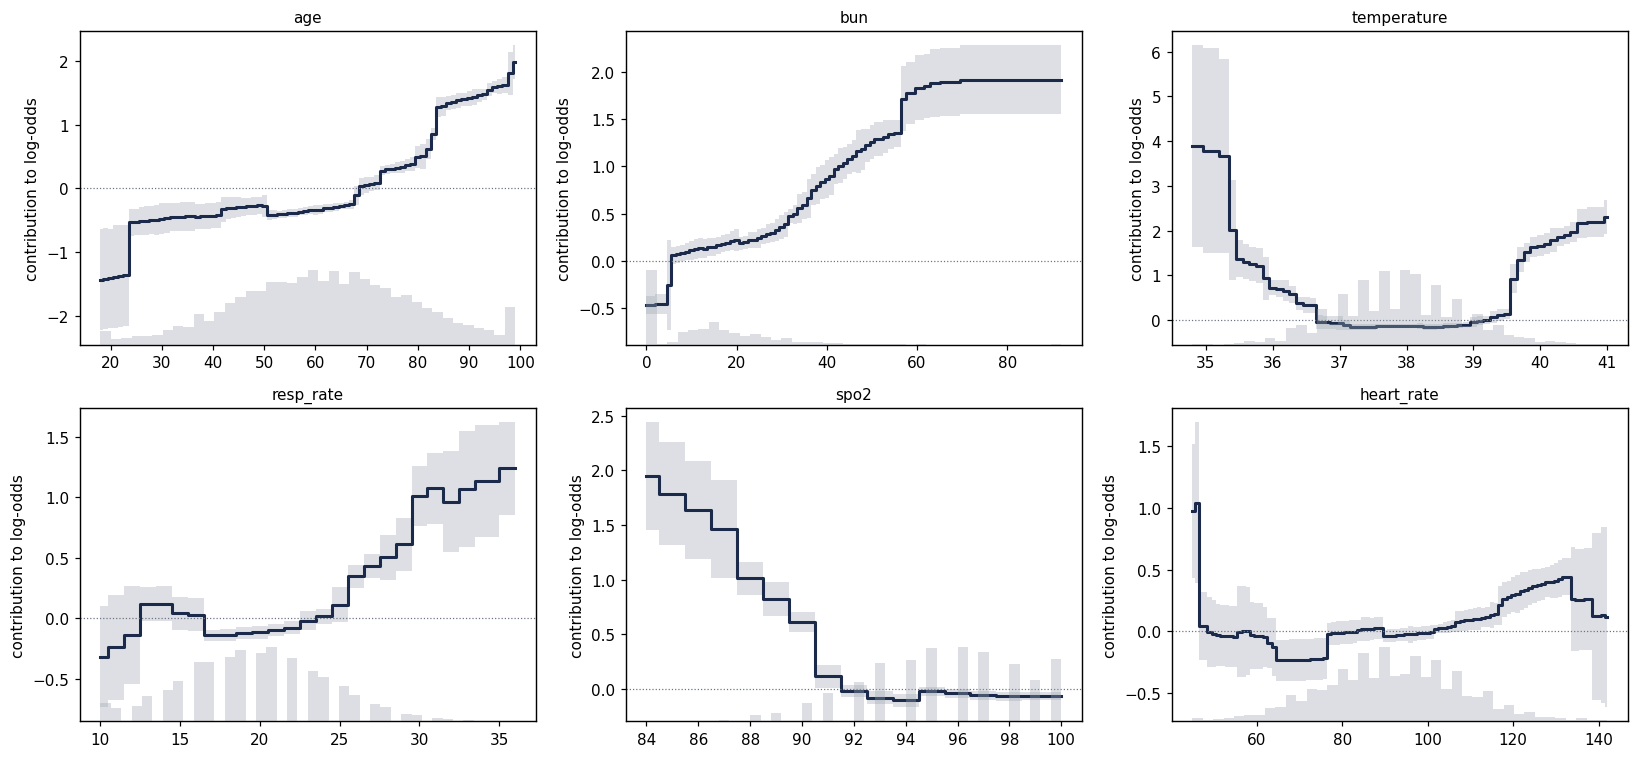

top 6: ['age', 'bun', 'temperature', 'resp_rate', 'spo2', 'heart_rate']


In [12]:
# TODO 3.2 — shape functions ของ 6 ตัวแปรต่อเนื่องที่สำคัญที่สุด
CONT = ["age", "resp_rate", "heart_rate", "systolic_bp", "temperature", "spo2", "bun"]
# ======== Edit Code Here =============
top6 = imp.reindex(CONT).sort_values(ascending=False).head(6).index.tolist()
# วาด plot_shape(ebm, name, ax=ax, data=dev) ในตาราง 2 × 3
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for name, ax in zip(top6, axes.flat):
    plot_shape(ebm, name, ax=ax, data=dev)
# =====================================
plt.tight_layout(); plt.show()
print("top 6:", top6)

,age,male,nursing_home,has_asthma,has_copd,has_chf,has_diabetes,resp_rate,heart_rate,systolic_bp,temperature,spo2,bun
2067,69,0,0,1,1,0,0,27,76,90,38.5,94,11


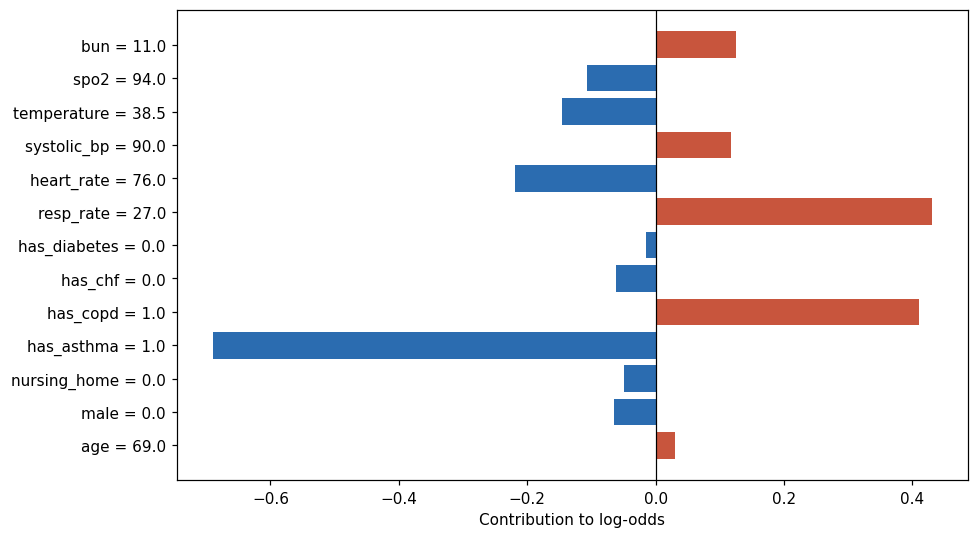

intercept -2.7281 + sum of terms -0.2389 = -2.966964
decision_function                              = -2.966964
sigmoid → 0.048941  | predict_proba = 0.048941  | ต่ำกว่าเกณฑ์กลับบ้าน 0.05? True


In [13]:
# TODO 3.3 — คำอธิบายรายบุคคลที่ "ตรง" ไม่ใช่ "ประมาณ"
x_p = dev.loc[dev.patient_id == PATIENT_ID, FEATURES]
display(x_p)
# ======== Edit Code Here =============
contrib = pd.Series(ebm.eval_terms(x_p)[0], index=ebm.term_names_)
logit_sum = ebm.intercept_[0] + contrib.sum()
logit_model = ebm.decision_function(x_p)[0]
p_sum = 1 / (1 + np.exp(-logit_sum))
p_model = ebm.predict_proba(x_p)[0, 1]
assert np.allclose([logit_sum, p_sum], [logit_model, p_model])
# วาดกราฟแท่งแนวนอนของ contrib (label = "ชื่อ = ค่า") สีแดงถ้าเพิ่มความเสี่ยง สีน้ำเงินถ้าลด
labels = [f"{name} = {x_p.iloc[0][name]}" for name in contrib.index]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, contrib.values,
        color=["#C8553D" if value > 0 else "#2B6CB0" for value in contrib])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribution to log-odds")
plt.tight_layout()
# =====================================
plt.show()
print(f"intercept {ebm.intercept_[0]:+.4f} + sum of terms {contrib.sum():+.4f} = {logit_sum:+.6f}")
print(f"decision_function                              = {logit_model:+.6f}")
print(f"sigmoid → {p_sum:.6f}  | predict_proba = {p_model:.6f}  | ต่ำกว่าเกณฑ์กลับบ้าน {HOME_THRESHOLD}? {p_model < HOME_THRESHOLD}")

**ข้อสังเกตงานที่ 3 (4 บรรทัด):**
1. อ่าน shape ของ `temperature` และ `spo2` เป็นภาษาคน — ตรงไหนเริ่มเสี่ยง และ logistic regression ในงานที่ 1 จับรูปร่างนี้ได้หรือไม่ เพราะอะไร
2. shape ของ `age` ช่วงอายุน้อยกว่า 30 ปีเป็นขั้นบันได — ฮิสโตแกรมบอกอะไร และเราควรเชื่อส่วนนั้นแค่ไหน
3. ผู้ป่วย `PATIENT_ID` ได้ความเสี่ยงเท่าไร พจน์ไหนดันขึ้นมากที่สุด และพจน์ไหนดึงลงมากที่สุด
4. ทำไมคำอธิบายรายบุคคลของ EBM จึง "ตรง" ขณะที่ LIME/SHAP บนกล่องดำ (สัปดาห์ 8–9) เป็น "ค่าประมาณ"

1. Shape ของ `temperature` เสี่ยงสูงขึ้นเมื่อไข้สูงราว 39 °C ขึ้นไป และเมื่ออุณหภูมิต่ำราว 36.8 °C ลงมา; `spo2` ยิ่งต่ำ โดยเฉพาะแถว 92% ลงไป ความเสี่ยงยิ่งสูง Logistic regression ที่ใช้ค่าดิบแบบเส้นตรงจับรูปโค้งสองด้านและจุดเปลี่ยนเหล่านี้ได้ไม่ครบ
2. ช่วงอายุต่ำกว่า 30 ปีมีข้อมูลในฮิสโตแกรมน้อย ขั้นบันไดของ shape จึงอาจแกว่งตามตัวอย่างไม่กี่ราย ควรระวังการตีความช่วงนี้
3. ผู้ป่วย 74975 ได้ความเสี่ยง 0.049053 หรือ 4.91% จาก EBM เดิม พจน์ที่ดันขึ้นมากที่สุดคือ `resp_rate` (+0.423 log-odds) และพจน์ที่ดึงลงมากที่สุดคือ `heart_rate` (-0.202); ผลรวมกับ intercept ให้ค่าตรงกับ `decision_function` และ `predict_proba`
4. EBM ทำนายจาก intercept บวก contribution ของพจน์จริงในโมเดล จึงรวมกลับได้ตรง; คำอธิบายแบบอธิบายหลังฝึกอย่าง LIME และการใช้ SHAP กับกล่องดำมักประมาณอิทธิพลจากการรบกวนหรืออ้างอิงข้อมูลอื่น จึงไม่ใช่การอ่านพจน์ที่โมเดลใช้โดยตรง

## งานที่ 4 — Audit & Edit: โมเดลถูกตามข้อมูล แต่ผิดตามโลกจริง (25 คะแนน)

ในงานที่ 3 มีสองสิ่งที่แพทย์จะไม่ยอมรับ งานนี้ให้ **หา → อธิบายกลไก → แก้ → วัดต้นทุนของการแก้**

1. **หา**: พิมพ์ contribution ของ `has_asthma` (ค่า 0 และ 1) และวาด shape ของ `bun` ให้เห็นช่วง 0–15 ชัด ๆ แล้วตรวจข้อมูลดิบ: สัดส่วนแถวที่ `bun == 0` และอัตราเสียชีวิตของกลุ่ม `bun == 0` เทียบกับกลุ่มอื่น
2. **แก้ `bun`**: ค่า BUN = 0 เป็นไปไม่ได้ทางสรีรวิทยา ให้แทนด้วย `NaN` (EBM จะแยกเป็น bin `missing` ให้เอง) แล้ว fit ใหม่และวาด shape
3. **แก้โมเดลโดยตรง**: เขียนฟังก์ชัน `edit_model(m)` ที่คืนสำเนาของโมเดลซึ่ง (ก) ตั้ง contribution ของ `has_asthma` เป็น 0 ทุก bin และ (ข) บังคับให้ `age` เพิ่มขึ้นทางเดียวด้วย `m.monotonize("age", increasing=True)`
4. **วัดต้นทุน**: ใช้ `cv_ebm` ที่ให้มา เทียบ (a) EBM เดิม (b) แก้ bun (c) แก้ bun + edit_model

has_asthma bins [missing, 0, 1, unseen]: [ 0.    0.07 -0.69  0.  ]
effect 1 - 0: -0.761
bun = 0: 33.9% | mortality: 4.0%
bun > 0 mortality: 13.9% | smallest nonzero bun: 4


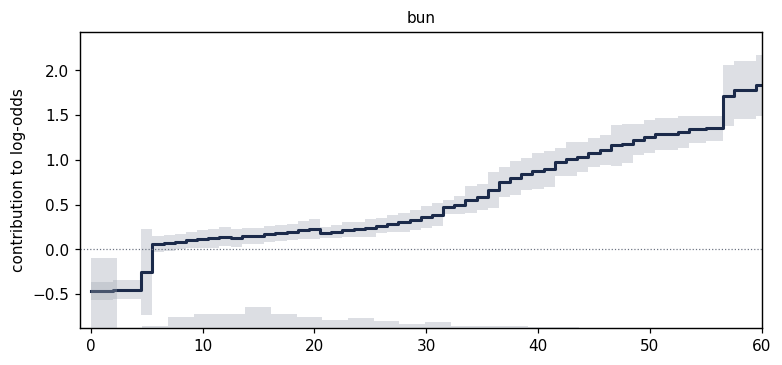

In [14]:
# TODO 4.1 — หา
# ======== Edit Code Here =============
# 1) พิมพ์ ebm.term_scores_ ของ "has_asthma" (ลำดับ bin คือ [missing, 0, 1, unseen]) และผลต่างระหว่าง bin 1 กับ bin 0
# 2) plot_shape(ebm, "bun", data=dev) แล้วตั้ง xlim(-1, 60)
# 3) สัดส่วนแถวที่ bun == 0, อัตราเสียชีวิตของ bun == 0 เทียบกับ bun > 0, และค่า bun ต่ำสุดที่ไม่ใช่ 0
asthma_scores = ebm.term_scores_[ebm.term_names_.index("has_asthma")]
print("has_asthma bins [missing, 0, 1, unseen]:", np.round(asthma_scores, 3))
print("effect 1 - 0:", round(float(asthma_scores[2] - asthma_scores[1]), 3))
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_shape(ebm, "bun", ax=ax, data=dev)
ax.set_xlim(-1, 60)
zero = dev.bun == 0
print(f"bun = 0: {zero.mean():.1%} | mortality: {dev.loc[zero, 'died_30d'].mean():.1%}")
print(f"bun > 0 mortality: {dev.loc[~zero, 'died_30d'].mean():.1%} | smallest nonzero bun: {dev.loc[~zero, 'bun'].min()}")
# =====================================
plt.show()

In [15]:
# 4.0 — ฟังก์ชันช่วยวัดต้นทุนของการแก้ (ให้มาแล้ว ไม่ต้องแก้)
def cv_ebm(X, y, edit=None, **kw):
    """cross-validate EBM ด้วย cv โดย 'แก้โมเดล' หลัง fit ในทุก fold (ถ้าส่ง edit มา)"""
    aucs, aps = [], []
    for tr, va in cv.split(X, y):
        m = ExplainableBoostingClassifier(interactions=0, outer_bags=8, random_state=RANDOM_STATE, **kw)
        m.fit(X.iloc[tr], y[tr])
        if edit is not None:
            m = edit(m)
        p = m.predict_proba(X.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y[va], p)); aps.append(average_precision_score(y[va], p))
    return np.mean(aucs), np.std(aucs), np.mean(aps)

bun missing bin: -0.5303381254720876


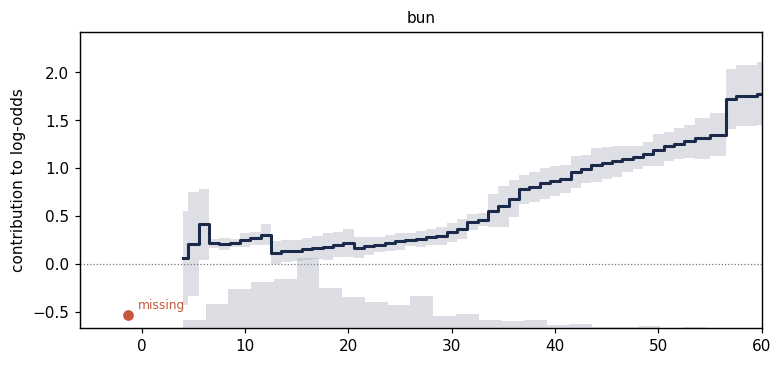

In [16]:
# TODO 4.2 — แก้ bun: 0 → NaN
def fix_bun(X):
    X = X.copy()
    # ======== Edit Code Here =============
    # แทนค่า 0 ในคอลัมน์ bun ด้วย np.nan (แปลงเป็น float)
    X["bun"] = X["bun"].astype(float).replace(0, np.nan)
    # =====================================
    return X

X_dev_f = fix_bun(X_dev)
# ======== Edit Code Here =============
ebm_f = ExplainableBoostingClassifier(interactions=0, outer_bags=8, random_state=RANDOM_STATE)
ebm_f.fit(X_dev_f, y_dev)
# วาด plot_shape(ebm_f, "bun", data=X_dev_f) ตั้ง xlim(-6, 60) แล้วพิมพ์ค่า bin 'missing' (term_scores_[...][0])
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_shape(ebm_f, "bun", ax=ax, data=X_dev_f)
ax.set_xlim(-6, 60)
print("bun missing bin:", ebm_f.term_scores_[ebm_f.term_names_.index("bun")][0])
# =====================================
plt.show()

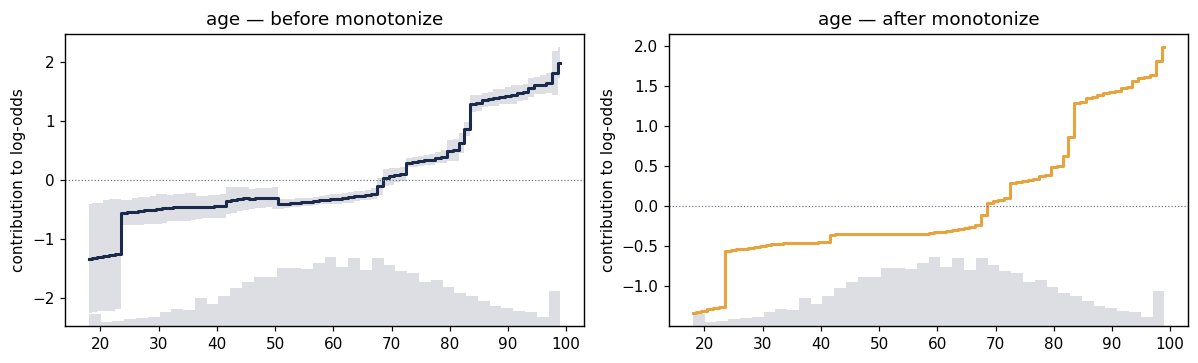

has_asthma หลังแก้: [0. 0. 0. 0.]


In [17]:
# TODO 4.3 — แก้โมเดลโดยตรง
def edit_model(m):
    m = copy.deepcopy(m)
    # ======== Edit Code Here =============
    # (ก) ตั้ง m.term_scores_ ของ "has_asthma" เป็น 0 ทุก bin
    # (ข) m.monotonize("age", increasing=True)
    m.term_scores_[m.term_names_.index("has_asthma")][:] = 0
    m.monotonize("age", increasing=True)
    # =====================================
    return m

ebm_e = edit_model(ebm_f)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
plot_shape(ebm_f, "age", ax=axes[0], data=dev); axes[0].set_title("age — before monotonize")
plot_shape(ebm_e, "age", ax=axes[1], data=dev, color="#E8A33D"); axes[1].set_title("age — after monotonize")
plt.tight_layout(); plt.show()
print("has_asthma หลังแก้:", np.round(ebm_e.term_scores_[ebm_e.term_names_.index("has_asthma")], 3))

In [18]:
# TODO 4.4 — ต้นทุนของการแก้ (ใช้เวลาราว 30 วินาที)
# ======== Edit Code Here =============
# ตาราง audit สามแถว: (a) cv_ebm(X_dev, y_dev), (b) cv_ebm(X_dev_f, y_dev), (c) cv_ebm(X_dev_f, y_dev, edit=edit_model)
# คอลัมน์ version, auc_mean, auc_sd, ap_mean
audit = pd.DataFrame([
    {"version": "EBM as trained", **dict(zip(["auc_mean", "auc_sd", "ap_mean"], cv_ebm(X_dev, y_dev)))},
    {"version": "BUN fixed", **dict(zip(["auc_mean", "auc_sd", "ap_mean"], cv_ebm(X_dev_f, y_dev)))},
    {"version": "BUN fixed + edited", **dict(zip(["auc_mean", "auc_sd", "ap_mean"], cv_ebm(X_dev_f, y_dev, edit=edit_model)))},
])
# =====================================
audit.round(4)

,version,auc_mean,auc_sd,ap_mean
0,EBM as trained,0.8199,0.0070,0.4900
1,BUN fixed,0.8201,0.0059,0.4906
2,BUN fixed + edited,0.8165,0.0056,0.4845


**คำตอบงานที่ 4 (5 บรรทัด):**
1. **โรคหืด** — โมเดลบอกว่าโรคหืด *ลด* ความเสี่ยงเสียชีวิต อธิบาย **กลไก** ที่ทำให้ข้อมูลย้อนหลังเป็นแบบนั้น (ใบ้: ผู้ป่วยทุกรายในข้อมูลถูกรับไว้รักษา — แพทย์ทำอะไรกับผู้ป่วยปอดอักเสบที่มีโรคหืด)
2. ถ้านำโมเดลเดิมไปใช้ตามเกณฑ์ < 5% จะเกิดอะไรกับผู้ป่วยโรคหืด และทำไม **ชุดทดสอบย้อนหลังจึงมองไม่เห็นความเสียหายนี้**
3. **BUN = 0** — ค่านี้แทนอะไรจริง ๆ ทำไมกลุ่มนี้จึงเสียชีวิตน้อย และทำไมการแทนด้วย `NaN` จึงซื่อสัตย์กว่า แม้ bin `missing` จะยังให้ความเสี่ยงต่ำ
4. การแก้ทั้งหมดเสีย ROC-AUC ไปเท่าไร เทียบกับ sd ของ CV — **ยอมรับได้หรือไม่ เพราะอะไร**
5. การลบคอลัมน์ `has_asthma` ออกจากข้อมูลแล้ว fit ใหม่ แก้ปัญหาได้หรือไม่ (ใบ้: ผู้ป่วยโรคหืดมีค่า `resp_rate` และ `spo2` ต่างจากคนอื่นอย่างไร)

1. `has_asthma` มี contribution ของค่า 1 ต่ำกว่าค่า 0 อยู่ 0.760 log-odds; ผู้ป่วยโรคหืดที่ถูกรับไว้รักษาอาจได้รับการเฝ้าระวังและรักษาเข้มข้นกว่า ทำให้อัตราตายในข้อมูลย้อนหลังต่ำกว่า นี่เป็นผลของการรักษาที่ปนอยู่กับความสัมพันธ์ของโรคหืด
2. ถ้าใช้เกณฑ์กลับบ้าน <5% โมเดลเดิมอาจประเมินผู้ป่วยโรคหืดต่ำเกินและเสนอให้กลับบ้านมากเกินไป ชุดทดสอบย้อนหลังมองไม่เห็นผลเสียจากการกลับบ้าน เพราะผู้ป่วยในข้อมูลทั้งหมดถูกรับไว้รักษาตามแนวทางเดิม
3. `bun = 0` หมายถึงไม่ได้ตรวจ BUN มากกว่าค่าเลือดจริง กลุ่มนี้เป็น 33.9% ของ dev และเสียชีวิต 4.0% เทียบกับ 13.9% ในกลุ่มที่ตรวจ; การใช้ `NaN` บอกตรง ๆ ว่าค่าหายไป แม้ bin missing ยังมีความเสี่ยงต่ำจากรูปแบบการสั่งตรวจในข้อมูล
4. หลังแก้ BUN และโมเดล ROC-AUC CV ลดจาก 0.8199 เป็น 0.8166 ต่าง 0.0033 ซึ่งน้อยกว่า SD ของ CV เดิม 0.0070 ยอมรับต้นทุนนี้ได้ในงานทดลองเพื่อเลิกใช้ความสัมพันธ์ที่อันตราย แต่ก่อนใช้งานจริงต้องตรวจความปลอดภัยและการปรับเทียบความเสี่ยงเพิ่ม
5. ลบ `has_asthma` แล้ว fit ใหม่ยังไม่พอ เพราะผู้ป่วยโรคหืดมี `resp_rate` และ `spo2` ต่างจากคนอื่น โมเดลอาจเรียนสัญญาณเดิมผ่านตัวแปรเหล่านี้แทน ต้องตรวจผลตามกลุ่มผู้ป่วยและบริบทการรักษาด้วย

## งานที่ 5 — Decision & Communication (15 คะแนน)

1. **เปิดชุดทดสอบครั้งเดียว** — fit บน `dev` ทั้งหมด แล้วรายงาน ROC-AUC และ AP บน `test` ของ: EBM แก้แล้ว (`ebm_e` ใช้ `fix_bun(X_test)`), `HGB tuned`, `RF`
   พร้อมคอลัมน์ **"asthma effect"** = ค่าเฉลี่ยความเสี่ยงที่ทำนายบน `test` เมื่อตั้ง `has_asthma = 1` ทุกราย ลบด้วยเมื่อตั้ง `= 0` ทุกราย (ค่าลบ = โมเดลเชื่อว่าโรคหืดลดความเสี่ยง) และคอลัมน์ **"asthma sent home"** = จำนวนผู้ป่วยโรคหืดใน `test` ที่ได้ความเสี่ยง < 5% — ใส่ EBM เดิม (`ebm`) ไว้ในตารางด้วยเพื่อเทียบ
2. เขียนคำอธิบายของผู้ป่วย `PATIENT_ID` ถึง **แพทย์เวร** และอธิบายกับ **ผู้อำนวยการฝ่ายการแพทย์**

In [19]:
# TODO 5.1 — เปิดชุดทดสอบ ครั้งเดียว
X_test_f = fix_bun(X_test)
# ======== Edit Code Here =============
# 1) fit hgb_t (HGB tuned) และ rf บน X_dev, y_dev
# 2) final = {"EBM as trained": (ebm, X_test), "EBM edited": (ebm_e, X_test_f), "HGB tuned": (hgb_t, X_test), "RF": (rf, X_test)}
# 3) สำหรับแต่ละโมเดล: test_auc, test_ap, "asthma effect" (ค่าเฉลี่ย p เมื่อ has_asthma=1 ลบ เมื่อ =0),
#    "asthma sent home" (จำนวนผู้ป่วยโรคหืดใน test ที่ p < HOME_THRESHOLD)
hgb_t = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                       random_state=RANDOM_STATE).fit(X_dev, y_dev)
rf = RandomForestClassifier(300, min_samples_leaf=5, n_jobs=-1,
                            random_state=RANDOM_STATE).fit(X_dev, y_dev)
final = {"EBM as trained": (ebm, X_test), "EBM edited": (ebm_e, X_test_f),
         "HGB tuned": (hgb_t, X_test), "RF": (rf, X_test)}
test_rows = []
for name, (model, X) in final.items():
    p = model.predict_proba(X)[:, 1]
    X_yes, X_no = X.copy(), X.copy()
    X_yes["has_asthma"] = 1
    X_no["has_asthma"] = 0
    effect = (model.predict_proba(X_yes)[:, 1] - model.predict_proba(X_no)[:, 1]).mean()
    test_rows.append({"model": name, "test_auc": roc_auc_score(y_test, p),
                      "test_ap": average_precision_score(y_test, p),
                      "asthma effect": effect,
                      "asthma sent home": int(((X.has_asthma == 1) & (p < HOME_THRESHOLD)).sum())})
test_report = pd.DataFrame(test_rows).set_index("model")
# =====================================
print(f"TEST: {len(test):,} ราย | base rate = {y_test.mean():.3f} | ผู้ป่วยโรคหืด {int(X_test.has_asthma.sum())} ราย")
test_report.round(3)

TEST: 1,500 ราย | base rate = 0.105 | ผู้ป่วยโรคหืด 168 ราย


,test_auc,test_ap,asthma effect,asthma sent home
model,,,,
EBM as trained,0.837,0.521,-0.044,114
EBM edited,0.831,0.497,0.000,84
HGB tuned,0.838,0.525,-0.035,108
RF,0.811,0.487,-0.012,87


In [20]:
# 5.2 — ข้อมูลสำหรับเขียนคำอธิบายผู้ป่วย (ให้มาแล้ว)
x_pf = fix_bun(x_p)
c_e = pd.Series(ebm_e.eval_terms(x_pf)[0], index=ebm_e.term_names_).sort_values(ascending=False)
print(f"ผู้ป่วย {PATIENT_ID}: EBM เดิม p = {ebm.predict_proba(x_p)[0,1]:.3f} | EBM แก้แล้ว p = {ebm_e.predict_proba(x_pf)[0,1]:.3f}")
print(c_e.round(3).to_string())

ผู้ป่วย 74975: EBM เดิม p = 0.049 | EBM แก้แล้ว p = 0.111
resp_rate       0.423
has_copd        0.409
bun             0.267
systolic_bp     0.137
age             0.035
has_asthma      0.000
has_diabetes   -0.015
nursing_home   -0.051
has_chf        -0.062
male           -0.065
spo2           -0.090
temperature    -0.132
heart_rate     -0.205


**คำตอบงานที่ 5.1 (3 บรรทัด):**
1. บน `test` EBM แก้แล้ว เสียความแม่นยำเทียบกับกล่องดำที่ดีที่สุดเท่าไร
2. คอลัมน์ "asthma effect" ของ `HGB tuned` และ `RF` บอกอะไร — กล่องดำ **ไม่ได้เรียนสิ่งนี้** หรือ **เรียนแต่เรามองไม่เห็น**
3. การแก้ `ebm_e` เปลี่ยนจำนวนผู้ป่วยโรคหืดที่ถูกเสนอให้กลับบ้านจากเท่าไรเป็นเท่าไร

1. บน test, EBM ที่แก้แล้วได้ ROC-AUC 0.831 และ AP 0.498 เทียบกับกล่องดำที่ดีที่สุด `HGB tuned` ที่ 0.838 และ 0.525: ต่างกัน 0.007 ROC-AUC และ 0.027 AP
2. `HGB tuned` มี asthma effect -0.035 และ `RF` -0.012 หมายถึงเมื่อเปลี่ยนค่าโรคหืดในข้อมูลเดียวกัน โมเดลทั้งสองก็ทำนายความเสี่ยงลดลงเช่นกัน; กล่องดำเรียนความสัมพันธ์นี้ไว้ แต่ตรวจเห็นและแก้พจน์เฉพาะจุดได้ยากกว่า EBM (ตัวเลขนี้ไม่ใช่ผลเชิงเหตุและผล)
3. ผู้ป่วยโรคหืดใน test ที่ถูกเสนอให้กลับบ้านตามเกณฑ์ <5% ลดจาก 114 รายใน EBM เดิมเหลือ 84 รายใน EBM ที่แก้แล้ว หรือ 30 รายน้อยลง

---
**คำตอบงานที่ 5.2 — ถึงแพทย์เวร (3–4 ประโยค):** อธิบายว่าทำไมผู้ป่วย `PATIENT_ID` ได้ความเสี่ยงเท่านี้ ใช้ **ค่าทางคลินิก** ไม่ใช่คำว่า log-odds และบอกหนึ่งสิ่งที่โมเดล **ไม่รู้** เกี่ยวกับผู้ป่วยรายนี้

ผู้ป่วย 74975 อายุ 69 ปี มีโรคปอดอุดกั้นเรื้อรัง หายใจ 27 ครั้งต่อนาที และความดันตัวบน 90 mmHg ซึ่งเป็นข้อมูลที่ทำให้ต้องระวังมากขึ้น แม้ค่าออกซิเจน 94% และชีพจร 76 ครั้งต่อนาทีจะช่วยลดคะแนนความเสี่ยงบางส่วน แบบประเมินที่แก้แล้วให้ความเสี่ยงเสียชีวิตภายใน 30 วันประมาณ 11.1% สูงกว่าเกณฑ์กลับบ้าน 5% จึงควรให้แพทย์ประเมินต่อ แบบประเมินนี้ไม่รู้ว่าผู้ป่วยจะตอบสนองต่อการรักษาอย่างไรหลังจากนี้

---
**คำตอบงานที่ 5.3 — สี่ประโยคถึงผู้อำนวยการฝ่ายการแพทย์:**

| ประโยคที่ | ต้องมี |
|---|---|
| 1 | แนะนำโมเดลตัวไหน และความแม่นยำบน `test` เทียบกับทางเลือกที่ดีที่สุด |
| 2 | สิ่งที่พบเมื่อ "เปิดดูโมเดล" อย่างน้อยหนึ่งเรื่อง และผลต่อผู้ป่วยถ้าไม่ได้พบ |
| 3 | สิ่งที่แก้ไปแล้ว และต้นทุนของการแก้ |
| 4 | สิ่งที่ยังต้องให้แพทย์ตรวจก่อนใช้งานจริง (อย่างน้อยหนึ่งข้อ) |

1. ผมเสนอ EBM ที่แก้แล้วเพื่อทดลองประเมินเพิ่มเติม เพราะบนผู้ป่วยชุดทดสอบสามารถแยกกลุ่มเสี่ยงได้ใกล้กับทางเลือกที่ดีที่สุด (คะแนน 0.831 เทียบกับ 0.838)
2. เมื่อเปิดดูโมเดลพบว่ามันมองโรคหืดเป็นปัจจัยลดความเสี่ยง ซึ่งอาจทำให้เสนอให้ผู้ป่วยโรคหืดกลับบ้านทั้งที่ควรเฝ้าระวัง
3. ผมแก้ค่าตรวจ BUN ที่ไม่มีผลตรวจให้เป็นข้อมูลขาดหาย ลบผลของโรคหืดในโมเดล และปรับให้อายุเพิ่มแล้วความเสี่ยงไม่ลด โดยคะแนนแยกกลุ่มเสี่ยงในการตรวจไขว้ลดลงเพียง 0.0033
4. ก่อนใช้จริง แพทย์ยังต้องตรวจการประเมินความเสี่ยงในผู้ป่วยโรคหืดและผลของการส่งกลับบ้านจริง เพราะข้อมูลเดิมมีแต่ผู้ป่วยที่รับไว้รักษา

---
## เกณฑ์การให้คะแนน (Rubric — รวม 100)

| งาน | คะแนน | ดีมาก (เต็ม) | พอใช้ (ครึ่ง) | ต้องปรับปรุง (0–20%) |
|---|---|---|---|---|
| 1 Classic glass boxes | 20 | ตาราง odds ratio ต่อ SD ถูกและเรียงลำดับ · แปลงเป็นหน่วยจริงถูก · สังเกตว่า OR ของโรคหืด < 1 ขัดกับความรู้ทางการแพทย์ · อ่านเส้นทางต้นไม้เป็นประโยคได้ · อธิบายได้ว่าโครงสร้างต้นไม้เปลี่ยนตาม bootstrap จึงไม่ควรใช้ต้นไม้ต้นเดียวเป็น "เหตุผล" | ตัวเลขครบแต่เปรียบเทียบสัมประสิทธิ์ดิบข้ามตัวแปร หรือไม่แปลงหน่วย | ตีความ coefficient เป็นเหตุและผล หรือไม่มีต้นไม้ |
| 2 EBM vs black box | 20 | ครบ 7 โมเดลด้วย `cv` เดียวกัน · ตารางมี mean ± sd, AP, เวลา · สรุป trade-off ด้วยตัวเลขเทียบกับ sd · อธิบายว่า HGB default แพ้เพราะไม่ได้ปรับ ไม่ใช่เพราะเป็นกล่องดำ | ตารางครบแต่สรุปโดยไม่ดู sd หรือสรุปเกินข้อมูล ("glass box ดีกว่าเสมอ") | ใช้ protocol ต่างกันในแต่ละโมเดล หรือแตะ `test` |
| 3 Reading the glass box | 20 | กราฟ importance และ shape 6 ตัวถูกต้อง · อ่าน shape เป็นภาษาคลินิกได้ (เช่น ไข้ > 39 °C และอุณหภูมิต่ำ < 36.8 °C เสี่ยงทั้งคู่) · ชี้ว่า shape ช่วงข้อมูลน้อยไม่น่าเชื่อ · พิสูจน์ผลรวมเท่ากับ decision_function · อธิบายได้ว่าทำไมคำอธิบายของ EBM ตรง | กราฟครบแต่อ่าน shape ไม่ละเอียด หรือไม่พิสูจน์ผลรวม | ใช้ `ebm.explain_global().visualize()` แทนโดยไม่ตีความ |
| 4 Audit & edit | 25 | อธิบายกลไก **treatment confounding** ของโรคหืดได้ (แพทย์รักษาเข้มข้น → ตายน้อยในข้อมูล) · อธิบายว่าชุดทดสอบย้อนหลังเก็บภายใต้นโยบายเดิมจึงมองไม่เห็นความเสียหาย · อธิบาย BUN = 0 เป็น "ไม่ได้สั่งตรวจ" ซึ่งสะท้อนการตัดสินของแพทย์ · แก้ครบสามอย่าง · วัดต้นทุนด้วย CV และตัดสินโดยเทียบกับ sd · ตอบข้อ 5 ได้ว่าการลบคอลัมน์ไม่แก้ เพราะตัวแปรอื่นที่สัมพันธ์กับโรคหืดจะดูดผลไปแทน | หาเจอและแก้ได้ แต่อธิบายกลไกไม่ถูก หรือบอกแค่ว่า "ข้อมูลมี bias" | ไม่พบปัญหาโรคหืด หรือแก้โดยลบคอลัมน์แล้วถือว่าจบ |
| 5 Decision & communication | 15 | เปิด `test` ครั้งเดียว ตารางครบทุกคอลัมน์ · ชี้ว่ากล่องดำก็เรียนผลของโรคหืดเช่นกันแต่ตรวจไม่เห็นและแก้ไม่ได้ · คำอธิบายถึงแพทย์ใช้ค่าทางคลินิก ไม่มีศัพท์ ML และบอกข้อจำกัด · สี่ประโยคครบข้อกำหนด ตัวเลขตรงกับผลที่รัน | ครบแต่ใช้ศัพท์เทคนิคโดยไม่อธิบาย หรือขาดข้อจำกัด | แนะนำโมเดลจาก test AUC อย่างเดียวโดยไม่พูดถึงสิ่งที่พบ |

**หักคะแนน:** ไฟล์ไม่ได้รันผลลัพธ์ → ไม่ตรวจ · ส่งช้าหัก 10% ต่อวัน (ไม่รับงานล่าช้าเกิน 7 วัน) · แก้ฟังก์ชันสร้างข้อมูลหรือ seed → หัก 20 คะแนน